In [3]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
#from treeple.experimental import StreamDecisionForest
import pandas as pd
#from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
#import xgboost as xgb

In [4]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
import numpy as np

In [5]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 1000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [6]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

**Torch MLP (customize available)**

In [ ]:
#(layer_wise_learning_rate, decay rate can be adjusted by yourself) if GPU avaliable
#Friendly if GPU avaliable
#Or runing script will be very slow (MLPRegressor is fast)

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class TorchMLP(nn.Module):
    def __init__(self, in_dim=57):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 128)
        self.fc2 = nn.Linear(128, 256)
        self.out = nn.Linear(256, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.out(x).squeeze(-1)
        return x

def fit_torch_mlp(
    X_train_np, Y_train_np,
    epochs=500,
    batch_size=32,
    lr_group=(3e-3, 1e-2, 1e-2),  # layer_wise_learning_rate: (fc1, fc2, out)
    weight_decay=1e-4,
    device=None,
    seed=42
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = TorchMLP(in_dim=X_train_np.shape[1]).to(device)
    X = torch.from_numpy(X_train_np).float()
    y = torch.from_numpy(Y_train_np).float()
    ds = TensorDataset(X, y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

    # Group of learning rate for each layer
    optimizer = optim.Adam(
        [
            {"params": model.fc1.parameters(), "lr": lr_group[0]},
            {"params": model.fc2.parameters(), "lr": lr_group[1]},
            {"params": model.out.parameters(), "lr": lr_group[2]},
        ],
        weight_decay=weight_decay,
    )
    loss_fn = nn.MSELoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model, device

@torch.no_grad()
def predict_torch(model, device, X_np):
    model.eval()
    X = torch.from_numpy(X_np).float().to(device)
    yhat = model(X).detach().cpu().numpy()
    return yhat


**Online ProForg**

In [ ]:


def make_XY(states, irewards, T_limit=None):
    """
    We use One hot Encoding for states
    """
    if T_limit is None:
        T_limit = len(irewards)
    X = np.hstack([
        position_encoder(states[:T_limit, 0], type="onehot"),
        states[:T_limit, 1:]    
    ])
    y = np.asarray(irewards[:T_limit]).reshape(-1)   
    return X, y

def build_Replay_pool(Pool_max_size=1000, T_per_session=200, base_seed=515, tdim=50):
    """ Replay buffer (optimization strategy for online learning) 
        Time embedding import from utils_online (t_dim=50)
    """
    X_list, y_list = [], []
    n_sess = int(np.ceil(Pool_max_size / T_per_session))
    for k in range(n_sess):
        actions_k, states_k, irewards_k, times_k = simulate_data_raw(
            rewards_in_period=rewards_in_period,
            session_duration=T_per_session, 
            tdim=tdim, n_sessions=1, seed=base_seed + k
        )
        Xk, yk = make_XY(states_k, irewards_k, T_limit=T_per_session)
        X_list.append(Xk)
        y_list.append(yk)
    X_pool = np.vstack(X_list)
    y_pool = np.concatenate(y_list)
    # Random pick batch from replay buffer
    idx = np.random.permutation(len(y_pool))
    X_pool = X_pool[idx]
    y_pool = y_pool[idx]
    return X_pool[:Pool_max_size], y_pool[:Pool_max_size]

# ========== Train and inference Function ==========
def train_model(X, Y):
    MLP = MLPRegressor(
            hidden_layer_sizes=(128, 128),
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=1000,          
            warm_start=True,        
            random_state=42,
            batch_size=32,
            early_stopping=False,
            verbose=False
        )
    MLP.fit(X, Y.reshape(-1))        # Make sure y's dim is 1
    return MLP

def predict_paths(MLP, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_paths.iloc[:, i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = MLP.predict(features)
    return preds

def choose_next_state(MLP, current_state, t_now, t_prime, gamma):
    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime)
    preds = predict_paths(MLP, df_paths, t_now, t_prime)
    rewards_matrix = preds[:, 1:]
    discounts = gamma ** np.arange(1, t_prime+1)
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    best_idx = np.argmax(total_disc)
    return int(df_paths.iloc[best_idx, 1]), df_paths, preds

def run_inference(MLP, start_state, T_p, t_prime, gamma, rewards_in_period):
    current_state = start_state
    future_states = [current_state]
    for delta_t in range(100):
        next_state, _, _ = choose_next_state(MLP, current_state, T_p + delta_t, t_prime, gamma)
        future_states.append(next_state)
        current_state = next_state
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma)
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma)
    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100
    return pregret

# ========== Main Loop ==========
T = 200 # Warmup length                
T_online = 400 # Online length     
gamma = 0.5
t_prime = 6
PREGRETS = []

for rep in range(5):
    X_warm, y_warm = build_Replay_pool(Pool_max_size=1000, T_per_session=T, base_seed=515+rep, tdim=50)
    MLP = train_model(X_warm, y_warm)   # In warm up phase, no training every time step but once after it ends

    
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    X_train = X_warm.copy()
    Y_train = y_warm.copy()

    PREGRET = []
    current_state = states[T, 0]  # Start at T
    for delta_t in range(T_online):
        next_state, df_paths, preds = choose_next_state(MLP, current_state, T+delta_t, t_prime, gamma)
        next_time = T + 1 + delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1, -1)
        ])
        next_reward = reward_simulate(next_state, next_time - 1, rewards_in_period)

        X_train = np.vstack([X_train, next_features])
        Y_train = np.append(Y_train, next_reward)

        # warm_start=True
        MLP = train_model(X_train, Y_train)

        current_state = next_state
        T_p = delta_t + T
        pregret_val = run_inference(MLP, current_state, T_p, t_prime, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS.append(PREGRET)
    np.savez_compressed(
        f"results_Online_ProForg_600_rep{rep}.npz",
        pregret=np.array(PREGRET),
        rep=rep,
        T=T,
        gamma=gamma,
        t_prime=t_prime
    )
    print(f"rep {rep} results saved to results_rep{rep}.npz")


rep 0, T_train 200, pregret=1.5225
rep 0, T_train 201, pregret=1.4717
rep 0, T_train 202, pregret=1.4558
rep 0, T_train 203, pregret=1.4750
rep 0, T_train 204, pregret=1.4493
rep 0, T_train 205, pregret=1.4493
rep 0, T_train 206, pregret=1.4493
rep 0, T_train 207, pregret=1.4437
rep 0, T_train 208, pregret=1.4347
rep 0, T_train 209, pregret=1.4381
rep 0, T_train 210, pregret=1.6379
rep 0, T_train 211, pregret=1.7519
rep 0, T_train 212, pregret=1.4473
rep 0, T_train 213, pregret=1.8645
rep 0, T_train 214, pregret=1.4274
rep 0, T_train 215, pregret=1.8862
rep 0, T_train 216, pregret=1.8815
rep 0, T_train 217, pregret=1.2174
rep 0, T_train 218, pregret=1.1036
rep 0, T_train 219, pregret=1.0348
rep 0, T_train 220, pregret=1.6697
rep 0, T_train 221, pregret=1.7565
rep 0, T_train 222, pregret=1.8236
rep 0, T_train 223, pregret=1.3836
rep 0, T_train 224, pregret=1.8846
rep 0, T_train 225, pregret=1.4251
rep 0, T_train 226, pregret=1.9001
rep 0, T_train 227, pregret=1.4250
rep 0, T_train 228, 

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_15892\3834232492.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('GnBu')


Text(0.5, 1.0, 'Prospective Regret Across Lookahead Steps - Online ProForg')

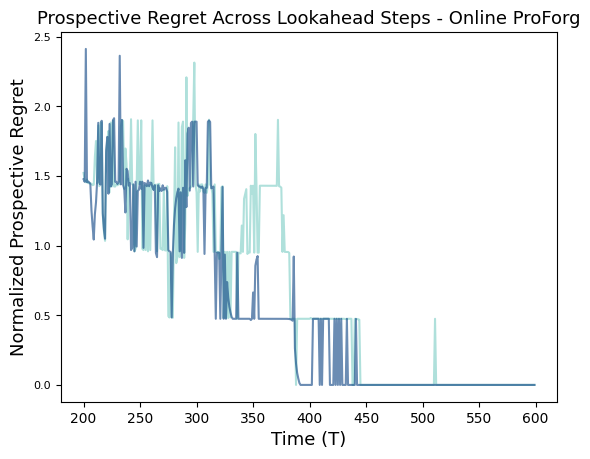

In [ ]:
cmap = cm.get_cmap('GnBu')
fontsize = 13
cmap_color = [cmap(0.5 + i*0.5) for i in range(3)]
for i in range(3):
    plt.plot(np.arange(200,600),PREGRETS[i],alpha = 0.6,color = cmap_color[i])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.xscale('log')
plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)

**Random Walk ProForg**

In [ ]:
from sklearn.neural_network import MLPRegressor
import numpy as np

def make_XY(states, irewards, T_limit=None):
    if T_limit is None:
        T_limit = len(irewards)
    X = np.hstack([
        position_encoder(states[:T_limit, 0], type="onehot"),
        states[:T_limit, 1:]     
    ])
    y = np.asarray(irewards[:T_limit]).reshape(-1)   
    return X, y

def build_Replay_pool(Pool_max_size=1000, T_per_session=200, base_seed=515, tdim=50):
    """ Replay buffer (optimization strategy for online learning) 
        Time embedding import from utils_online (t_dim=50)
    """
    X_list, y_list = [], []
    n_sess = int(np.ceil(Pool_max_size / T_per_session))
    for k in range(n_sess):
        actions_k, states_k, irewards_k, times_k = simulate_data_raw(
            rewards_in_period=rewards_in_period,
            session_duration=T_per_session, 
            tdim=tdim, n_sessions=1, seed=base_seed + k
        )
        Xk, yk = make_XY(states_k, irewards_k, T_limit=T_per_session)
        X_list.append(Xk)
        y_list.append(yk)
    X_pool = np.vstack(X_list)
    y_pool = np.concatenate(y_list)
    # Random pick batch from replay buffer
    idx = np.random.permutation(len(y_pool))
    X_pool = X_pool[idx]
    y_pool = y_pool[idx]
    return X_pool[:Pool_max_size], y_pool[:Pool_max_size]

# ========== Train and inference function==========
def train_model(X, Y):
    MLP = MLPRegressor(
            hidden_layer_sizes=(128, 128),
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=1000,          
            warm_start=True,        
            random_state=42,
            batch_size=32,
            early_stopping=False,
            verbose=False
        )
    MLP.fit(X, Y.reshape(-1))        # make sure dimension
    return MLP

def predict_paths(MLP, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_paths.iloc[:, i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = MLP.predict(features)
    return preds

def choose_next_state(MLP, current_state, t_now, t_prime, gamma):
    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime)
    preds = predict_paths(MLP, df_paths, t_now, t_prime)
    rewards_matrix = preds[:, 1:]
    discounts = gamma ** np.arange(1, t_prime+1)
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    best_idx = np.argmax(total_disc)
    return int(df_paths.iloc[best_idx, 1]), df_paths, preds

def run_inference(MLP, start_state, T_p, t_prime, gamma, rewards_in_period):
    current_state = start_state
    future_states = [current_state]
    for delta_t in range(100):
        next_state, _, _ = choose_next_state(MLP, current_state, T_p + delta_t, t_prime, gamma)
        future_states.append(next_state)
        current_state = next_state
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma)
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma)
    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100
    return pregret

# ========== Main Loop==========
T = 200                
T_online = 400              
gamma = 0.5
t_prime = 6
PREGRETS_Random = []

for rep in range(5):
    X_warm, y_warm = build_Replay_pool(Pool_max_size=1000, T_per_session=T, base_seed=515+rep, tdim=50)
    MLP = train_model(X_warm, y_warm)  

    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep+1998
    )

    X_train = X_warm.copy()
    Y_train = y_warm.copy()

    PREGRET = []
    current_state = states[T, 0]  
    for delta_t in range(T_online):
        next_state, df_paths, preds = choose_next_state(MLP, current_state, T+delta_t, t_prime, gamma)
        next_time = T + 1 + delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1, -1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)
        #Input random walk data every time
        X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        Y_train = irewards[:T+delta_t]
        MLP = train_model(X_train, Y_train)

        current_state = next_state  #  forward

        T_p = delta_t + T
        pregret_val = run_inference(MLP, current_state, T_p, t_prime, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS_Random.append(PREGRET)
    np.savez_compressed(
        f"results_rep{rep}.npz",
        pregret=np.array(PREGRETS_Random),
        rep=rep,
        T=T,
        gamma=gamma,
        t_prime=t_prime
    )
    print(f"rep {rep} results saved to results_random_walk_rep{rep}.npz")


rep 0, T_train 200, pregret=1.4582
rep 0, T_train 201, pregret=1.4578
rep 0, T_train 202, pregret=1.4569
rep 0, T_train 203, pregret=0.9839
rep 0, T_train 204, pregret=1.4517
rep 0, T_train 205, pregret=0.9734
rep 0, T_train 206, pregret=0.9595
rep 0, T_train 207, pregret=0.7703
rep 0, T_train 208, pregret=0.6566
rep 0, T_train 209, pregret=0.5877
rep 0, T_train 210, pregret=0.7477
rep 0, T_train 211, pregret=0.8437
rep 0, T_train 212, pregret=0.9015
rep 0, T_train 213, pregret=0.9436
rep 0, T_train 214, pregret=1.4338
rep 0, T_train 215, pregret=0.9780
rep 0, T_train 216, pregret=1.4587
rep 0, T_train 217, pregret=0.9817
rep 0, T_train 218, pregret=1.4497
rep 0, T_train 219, pregret=0.9763
rep 0, T_train 220, pregret=1.6474
rep 0, T_train 221, pregret=1.7615
rep 0, T_train 222, pregret=1.8329
rep 0, T_train 223, pregret=1.8750
rep 0, T_train 224, pregret=1.8986
rep 0, T_train 225, pregret=1.9001
rep 0, T_train 226, pregret=1.9094
rep 0, T_train 227, pregret=1.9094
rep 0, T_train 228, 

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_9256\2600717379.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('GnBu')


Text(0.5, 1.0, 'Random Walk ProForg')

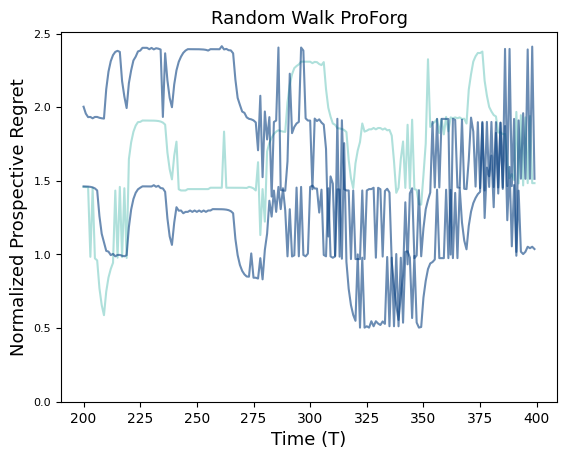

In [24]:
cmap = cm.get_cmap('GnBu')
fontsize = 13
cmap_color = [cmap(0.5 + i*0.5) for i in range(3)]
for i in range(3):
    plt.plot(np.arange(200,400),PREGRETS_Random[i],alpha = 0.6,color = cmap_color[i])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.xscale('log')
plt.title('Random Walk ProForg',fontsize = fontsize)